# Day 1 — euploid vs complex / trisomy / monosomy (**unreplicated**)

> ### Read this before running anything
>
> Day1 has **no embryo annotation** and **one sample per condition**. Ploidy is a *cell-intrinsic*
> property, so a euploid-vs-aneuploid contrast at day1 is a comparison made **entirely within a
> single library**.
>
> **There is no biological replication.** The biological unit is the embryo; day1 has one pool of
> embryos per condition and we cannot tell which cell came from which embryo. Consequently:
>
> * **DESeq2 cannot estimate biological dispersion.** With n=1 per group it has nothing to fit.
> * **Any p-value produced here describes cell-to-cell sampling noise, not reproducibility.**
>   It answers "would I see this again if I resampled cells from *this* library", not "would I
>   see this again in another embryo" — which is the question a reviewer is asking.
> * **Cell-level Wilcoxon (`sc.tl.rank_genes_groups`) is the worst offender**: with thousands of
>   cells it will return thousands of "significant" genes at padj < 1e-50, essentially all of
>   which are pseudoreplication.
>
> ### What this notebook therefore does
>
> | | |
> |---|---|
> | **Reports** | effect sizes (log2FC), pathway *directions*, activity scores |
> | **Does not report** | FDR-controlled gene lists presented as replicated findings |
> | **Primary use** | **concordance with the replicated day4/day6 result** (Section 6) — this is the one analysis that makes day1 genuinely load-bearing |
>
> Three estimators are run side by side (pseudobulk LFC, split-replicate DESeq2, cell-level
> Wilcoxon). **Genes are only trusted where all three agree in direction** — the agreement is the
> evidence, not any single p-value.
>
> If you need day1 to carry statistical weight in the paper, the fix is experimental, not
> computational: **demultiplex day1 to embryos** (you already have the barcode machinery), or
> run additional day1 samples.

## 0. Setup

In [2]:
import os, re, warnings, inspect
from datetime import date

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

warnings.simplefilter("ignore", FutureWarning)
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"

f"Last execution: {date.today()}"

/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'Last execution: 2026-07-14'

In [3]:
base_dir   = "/nfs/team292/rs40/projects/Aneuploid_screen_v2"
h5ad_in    = f"{base_dir}/processed_data/3_scanpy_integration/integrated_sub_adata.h5ad"
ploidy_csv = f"{base_dir}/processed_data/7_2_xclone/cell_karyotype_scploid.csv"

output_dir = f"{base_dir}/processed_data/13_day1_unreplicated"

fig_dir, tab_dir = f"{output_dir}/figures", f"{output_dir}/tables"
for d in (output_dir, fig_dir, tab_dir):
    os.makedirs(d, exist_ok=True)
sc.settings.figdir = fig_dir

# path to the REPLICATED day4/day6 results -- needed for Section 6
DAY46_DEG = f"{base_dir}/processed_data/12_pseudobulk_deseq2_gsea/tables/DESeq2_all_contrasts.csv"

COUNTS_LAYER = "counts"
REFERENCE    = "euploid"
TEST_GROUPS  = ["complex", "trisomy", "monosomy"]

MIN_CELLS_PER_GROUP = 30     # below this, don't even attempt a contrast
N_SPLITS            = 3      # pseudo-replicates per group (Section 3)
N_SEEDS             = 5      # re-run the split with this many seeds to expose instability
LFC_CUT             = 0.5

palette = {"euploid": "#C5C5C5", "trisomy": "#F26B3B",
           "monosomy": "#109E9D", "complex": "#662C91"}

# ---- analysis config ---------------------------------------------------
COUNTS_LAYER   = "counts"          # raw integer counts  <-- REQUIRED by DESeq2
CELLTYPE_COL   = "celltype_coarse"   # EPI / TE / unknown
PLOIDY_COL     = "ploidy"
KARYO_COL      = "karyotype"
TIMEPOINTS     = [ "day4", "day6"]  # timepoints with embryo annotation

REFERENCE      = "euploid"
TEST_GROUPS    = ["complex", "trisomy", "monosomy"]


## 1. Load day1 & confirm the replication structure

The printout below is the justification for everything else in this notebook. If it shows
one sample per condition, the rest follows.

In [4]:
adata = sc.read_h5ad(h5ad_in)

# ---- barcode / embryo assignment ---------------------------------------
BC_path = "/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv"
BC_df = pd.read_csv(BC_path)

# keep only what we need, avoid dragging in duplicate columns
#BC_df = BC_df[["cell.ID_", "filtered_feature_call", 'dataset']].drop_duplicates("cell.ID_")
BC_df["cell.ID_"] = BC_df["cell.ID_"] + "-1_" + BC_df['dataset']
BC_df = BC_df[["cell.ID_", "filtered_feature_call"]].drop_duplicates("cell.ID_")


# --- merge WITHOUT losing the AnnData index ---
obs = adata.obs.copy()
obs_index = obs.index                      # preserve it
obs = pd.merge(obs, BC_df, on="cell.ID_", how="left", suffixes=("", "_2"))
obs.index = obs_index                      # restore it
assert (obs.index == adata.obs_names).all(), "obs index misaligned after merge"
adata.obs = obs

print("cells with a feature call:",
      adata.obs["filtered_feature_call"].notna().sum(), "/", adata.n_obs)

cells with a feature call: 24225 / 38655


In [5]:
# ---- sanity check: raw counts present and actually integer -------------
assert COUNTS_LAYER in adata.layers, f"missing layer '{COUNTS_LAYER}'"

X = adata.layers[COUNTS_LAYER]
sample_vals = (X[:50].data if hasattr(X, "data") else np.asarray(X[:50])).ravel()
sample_vals = sample_vals[:1000]
is_int = np.allclose(sample_vals, np.round(sample_vals))
print(f"counts layer looks like integers: {is_int}")
print(f"max value: {sample_vals.max():.2f}  (log-transformed data would be small, e.g. < 15)")
assert is_int, "DESeq2 needs RAW integer counts, not log/normalised values."

counts layer looks like integers: True
max value: 124.00  (log-transformed data would be small, e.g. < 15)


In [6]:
# ---- attach ploidy calls (index-preserving) -----------------------------
ploidy_df = pd.read_csv(ploidy_csv, index_col=0)

# what the file brings in besides the join key
print("ploidy_df columns:", list(ploidy_df.columns))
ploidy_df = ploidy_df.drop_duplicates("cell").set_index("cell")

# avoid silent collisions if adata.obs already carries any of these names
clash = [c for c in ploidy_df.columns if c in adata.obs.columns]
if clash:
    print(f"dropping pre-existing obs columns that would collide: {clash}")
    adata.obs = adata.obs.drop(columns=clash)

# join by MAPPING through the key column -- index never moves
key = adata.obs["cell.ID_"].astype(str)
for col in ploidy_df.columns:                       # 'ploidy', 'karyotype', ...
    adata.obs[col] = key.map(ploidy_df[col]).values

assert (adata.obs.index == adata.obs_names).all(), "obs index misaligned"
print(f"ploidy assigned for {adata.obs['ploidy'].notna().sum():,} / {adata.n_obs:,} cells")

ploidy_df columns: ['cell', 'karyotype', 'ploidy', 'num_gain_chr', 'num_loss_chr', 'num_chr', 'num_abnormal_chr']
ploidy assigned for 38,655 / 38,655 cells


In [7]:
# ---- harmonise ploidy --------------------------------------------------
# adata with ploidy info
adata.obs["ploidy"] = pd.Categorical(
    adata.obs["ploidy"].astype(str).replace({"diploid": "euploid"}),
    categories=["euploid", "trisomy", "monosomy", "complex"],
    ordered=True,
)

# anything not in the 4 expected levels became NaN -- make sure that's only true NaNs
raw = adata.obs["ploidy"].astype(str)
unexpected = set(raw.unique()) - {"euploid", "trisomy", "monosomy", "complex", "nan", "None"}
if unexpected:
    print(f">>> WARNING: unrecognised ploidy labels dropped to NaN: {unexpected}")

print(adata.obs["ploidy"].value_counts(dropna=False))
# ---- cell type ---------------------------------------------------------
adata.obs["celltype"] = adata.obs[CELLTYPE_COL].astype(str)


ploidy
euploid     27380
complex      5842
trisomy      3298
monosomy     2135
Name: count, dtype: int64


In [8]:
# assumes `adata` is already built as in the main notebook (ploidy harmonised,
# celltype set, counts layer present). If running standalone, re-run that prep first.
adata_d1 = adata[(adata.obs["timepoint"] == "day1")
                 & adata.obs["ploidy"].notna()
                 & adata.obs["celltype"].notna()].copy()

print(f"day1 cells: {adata_d1.n_obs:,}\n")

# THE structural fact: how many independent samples back each group?
struct = (
    adata_d1.obs
    .groupby(["celltype", "ploidy"], observed=True)
    .agg(n_cells=("ploidy", "size"),
         n_samples=("sample", "nunique"),
         samples=("sample", lambda s: ",".join(sorted(s.unique()))))
    .reset_index()
)
struct.to_csv(f"{tab_dir}/day1_replication_structure.csv", index=False)
display(struct)

if struct["n_samples"].max() <= 1:
    print("\n>>> CONFIRMED: 1 sample per group. NO biological replication.")
    print(">>> All p-values below are cell-level and must NOT be reported as FDR-controlled findings.")
else:
    print("\n>>> Some groups span >1 sample -- you may be able to use a sample-level design instead.")

day1 cells: 6,839



,celltype,ploidy,n_cells,n_samples,samples
0,EPI,euploid,3313,2,"T1_control,T1_rev"
1,EPI,trisomy,695,2,"T1_control,T1_rev"
2,EPI,monosomy,216,2,"T1_control,T1_rev"
3,EPI,complex,780,2,"T1_control,T1_rev"
4,unspecified,euploid,822,2,"T1_control,T1_rev"
5,unspecified,trisomy,30,2,"T1_control,T1_rev"
6,unspecified,monosomy,65,2,"T1_control,T1_rev"
7,unspecified,complex,918,2,"T1_control,T1_rev"



>>> Some groups span >1 sample -- you may be able to use a sample-level design instead.


In [9]:
# Which contrasts have enough cells to be worth attempting at all?
contrasts = []
for ct in adata_d1.obs["celltype"].unique():
    if ct in ("doublet",):
        continue
    for grp in TEST_GROUPS:
        n_ref = ((adata_d1.obs["celltype"] == ct) & (adata_d1.obs["ploidy"] == REFERENCE)).sum()
        n_tst = ((adata_d1.obs["celltype"] == ct) & (adata_d1.obs["ploidy"] == grp)).sum()
        ok = (n_ref >= MIN_CELLS_PER_GROUP) and (n_tst >= MIN_CELLS_PER_GROUP)
        contrasts.append({"celltype": ct, "group": grp,
                          "n_euploid": int(n_ref), "n_test": int(n_tst), "run": ok})

contrasts = pd.DataFrame(contrasts)
display(contrasts)
to_run = [(r.celltype, r.group) for r in contrasts.itertuples() if r.run]
print("contrasts to run:", to_run)

,celltype,group,n_euploid,n_test,run
0,unspecified,complex,822,918,True
1,unspecified,trisomy,822,30,True
2,unspecified,monosomy,822,65,True
3,EPI,complex,3313,780,True
4,EPI,trisomy,3313,695,True
5,EPI,monosomy,3313,216,True


contrasts to run: [('unspecified', 'complex'), ('unspecified', 'trisomy'), ('unspecified', 'monosomy'), ('EPI', 'complex'), ('EPI', 'trisomy'), ('EPI', 'monosomy')]


## 2. Estimator A — pseudobulk log2FC (**no p-values, by design**)

Sum counts per `celltype × ploidy` → one pseudobulk profile per group → CPM → log2 ratio.

This is n=1 vs n=1. It gives an **effect size and nothing else**, which is exactly the honest
output. Genes are shrunk toward zero by their expression level (a crude analogue of DESeq2's
`lfcShrink`) so that low-count genes with wild ratios don't top the list.

In [10]:
def pseudobulk_lfc(ad, celltype, group, reference=REFERENCE, prior=8):
    """n=1 vs n=1 pseudobulk log2FC with expression-dependent shrinkage. No p-values."""
    sub = ad[(ad.obs["celltype"] == celltype) & (ad.obs["ploidy"].isin([reference, group]))]

    out = {}
    for lvl in [reference, group]:
        m = sub[sub.obs["ploidy"] == lvl].layers[COUNTS_LAYER]
        tot = np.asarray(m.sum(axis=0)).ravel()
        out[lvl] = tot

    ref_c, tst_c = out[reference], out[group]
    ref_cpm = ref_c / ref_c.sum() * 1e6
    tst_cpm = tst_c / tst_c.sum() * 1e6

    # shrinkage: prior pseudo-counts pull low-expression genes toward LFC = 0
    lfc = np.log2((tst_cpm + prior) / (ref_cpm + prior))

    return pd.DataFrame({
        "gene": sub.var_names,
        "cpm_euploid": ref_cpm,
        "cpm_test": tst_cpm,
        "baseMean_cpm": (ref_cpm + tst_cpm) / 2,
        "lfc_pseudobulk": lfc,
    }).set_index("gene")


lfc_pb = {}
for ct, grp in to_run:
    lfc_pb[(ct, grp)] = pseudobulk_lfc(adata_d1, ct, grp)
    print(f"{ct:>10} | {grp:>9} | genes with |LFC| > {LFC_CUT}: "
          f"{(lfc_pb[(ct,grp)]['lfc_pseudobulk'].abs() > LFC_CUT).sum():,}")

unspecified |   complex | genes with |LFC| > 0.5: 440
unspecified |   trisomy | genes with |LFC| > 0.5: 849
unspecified |  monosomy | genes with |LFC| > 0.5: 235
       EPI |   complex | genes with |LFC| > 0.5: 38
       EPI |   trisomy | genes with |LFC| > 0.5: 6
       EPI |  monosomy | genes with |LFC| > 0.5: 9


2026-07-14 21:24:53 | [INFO] maxp pruned
2026-07-14 21:24:53 | [INFO] cmap pruned
2026-07-14 21:24:53 | [INFO] kern dropped
2026-07-14 21:24:53 | [INFO] post pruned
2026-07-14 21:24:53 | [INFO] FFTM dropped
2026-07-14 21:24:53 | [INFO] GPOS pruned
2026-07-14 21:24:53 | [INFO] GSUB pruned
2026-07-14 21:24:53 | [INFO] glyf pruned
2026-07-14 21:24:53 | [INFO] Added gid0 to subset
2026-07-14 21:24:53 | [INFO] Added first four glyphs to subset
2026-07-14 21:24:53 | [INFO] Closing glyph list over 'MATH': 62 glyphs before
2026-07-14 21:24:53 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'Y', 'a', 'c', 'colon', 'd', 'e', 'eight', 'equal', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'y', 'z', 'zero']
2026-07-14 21:24:53 | [INFO]

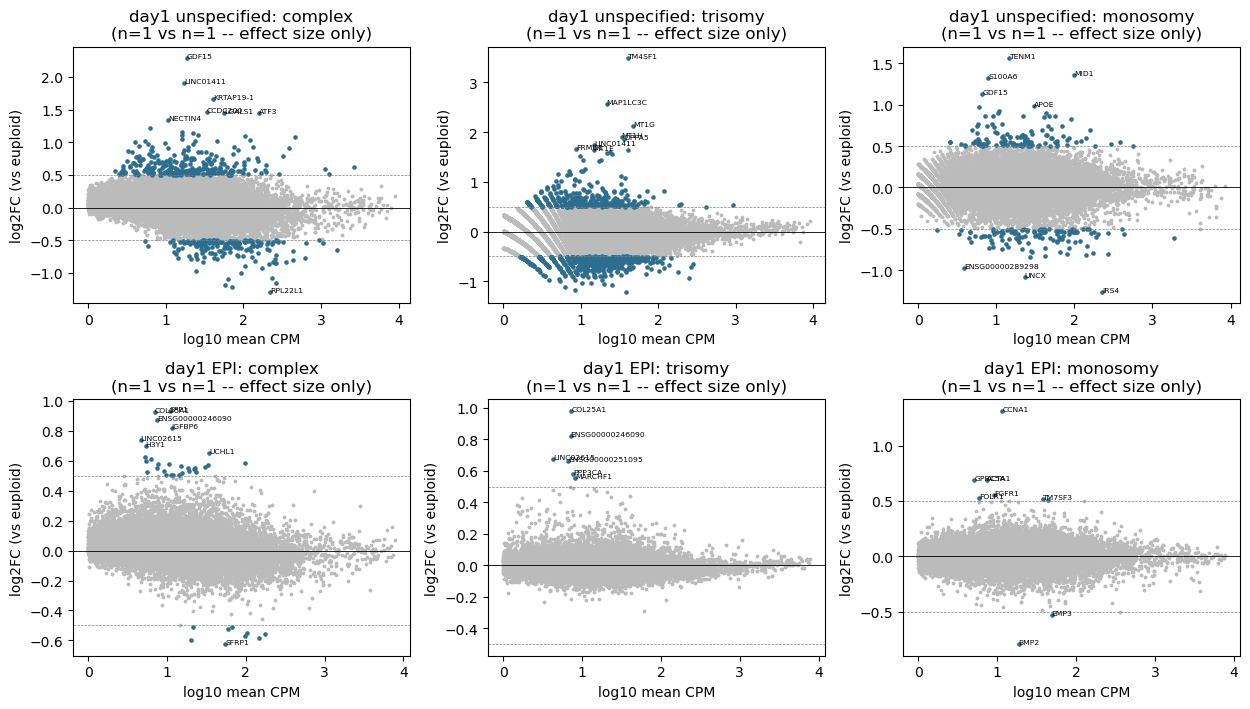

In [11]:
# MA plot -- the honest day1 visual. Effect size vs expression, no significance colouring.
if lfc_pb:
    n = len(lfc_pb); ncol = 3; nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.6*nrow), squeeze=False)
    for ax, ((ct, grp), d) in zip(axes.ravel(), lfc_pb.items()):
        d = d[d["baseMean_cpm"] > 1]
        ax.scatter(np.log10(d["baseMean_cpm"]), d["lfc_pseudobulk"],
                   s=3, c="#BBBBBB", rasterized=True)
        big = d[d["lfc_pseudobulk"].abs() > LFC_CUT]
        ax.scatter(np.log10(big["baseMean_cpm"]), big["lfc_pseudobulk"],
                   s=5, c="#2C6E91", rasterized=True)
        for g, r in big.reindex(big["lfc_pseudobulk"].abs().nlargest(8).index).iterrows():
            ax.text(np.log10(r["baseMean_cpm"]), r["lfc_pseudobulk"], g, fontsize=5.5)
        ax.axhline(0, lw=0.6, c="k")
        for v in (-LFC_CUT, LFC_CUT):
            ax.axhline(v, ls="--", lw=0.5, c="grey")
        ax.set(xlabel="log10 mean CPM", ylabel="log2FC (vs euploid)",
               title=f"day1 {ct}: {grp}\n(n=1 vs n=1 -- effect size only)")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/day1_MA_pseudobulk.pdf", bbox_inches="tight", dpi=300)
    plt.show()

## 3. Estimator B — split-replicate DESeq2 (**anti-conservative; use for ranking only**)

Randomly partition the cells of each group into `N_SPLITS` pseudo-replicates and run DESeq2
on those.

**Be clear about what this does and does not do.** Random splitting makes the replicates
*artificially homogeneous*: it captures technical/sampling variance but **destroys the embryo
structure that would generate real biological variance**. DESeq2 therefore sees a dispersion
that is too small and the p-values are **anti-conservative** — too many genes will look
significant.

It is included because it produces a *stable ranking* (better than raw n=1 LFC) and because it
lets us quantify the instability directly: we repeat the split with `N_SEEDS` different seeds
and keep only genes that survive every seed. **Treat the output as a ranking, not as inference.**

In [30]:
def split_replicate_deseq(ad, celltype, group, reference=REFERENCE,
                          n_splits=N_SPLITS, seed=0, n_cpus=4):
    """DESeq2 on RANDOM pseudo-replicates. Anti-conservative -- ranking only."""
    rng = np.random.default_rng(seed)
    sub = ad[(ad.obs["celltype"] == celltype)
             & (ad.obs["ploidy"].isin([reference, group]))].copy()

    # assign each cell to a random split WITHIN its ploidy group
    split = pd.Series(index=sub.obs_names, dtype=object)
    for lvl in [reference, group]:
        idx = sub.obs_names[sub.obs["ploidy"] == lvl]
        lab = rng.integers(0, n_splits, size=len(idx))
        split[idx] = [f"{lvl}.rep{i}" for i in lab]
    sub.obs["split"] = split
    sub.obs["pb_group"] = sub.obs["ploidy"].astype(str)

    pb = dc.pp.pseudobulk(sub, sample_col="split", groups_col="pb_group",
                          layer=COUNTS_LAYER, mode="sum")
    pb.obs["ploidy"] = pb.obs["pb_group"].astype(str)

    if pb.obs["ploidy"].value_counts().min() < 2:
        return None
    
    # drop empty / near-empty pseudo-replicates BEFORE anything divides by lib size
    lib = np.asarray(pb.X.sum(axis=1)).ravel()
    pb = pb[lib >= 1000].copy()          # same spirit as MIN_COUNTS
    if pb.obs["ploidy"].value_counts().min() < 2:
        return None                       # not enough reps left on one side

    dc.pp.filter_by_expr(pb, group="ploidy", min_count=10, min_total_count=15)

    try:
        try:
            dds = DeseqDataSet(adata=pb, design="~ploidy", refit_cooks=True,
                               n_cpus=n_cpus, quiet=True)
        except TypeError:
            dds = DeseqDataSet(adata=pb, design_factors=["ploidy"], refit_cooks=True,
                               n_cpus=n_cpus, quiet=True)
        dds.deseq2()
        st = DeseqStats(dds, contrast=["ploidy", group, reference], n_cpus=n_cpus, quiet=True)
        st.summary()
        return st.results_df.copy()
    except Exception as e:
        print(f"   split-DESeq2 failed ({celltype}/{group}, seed={seed}): {e}")
        return None

In [ ]:
# Run across seeds -- the spread across seeds IS the instability of this estimator.
split_res, stability = {}, []

for ct, grp in to_run:
    per_seed = {}
    for s in range(N_SEEDS):
        r = split_replicate_deseq(adata_d1, ct, grp, seed=s)
        if r is not None:
            per_seed[s] = r
    if not per_seed:
        continue

    # genes significant in EVERY seed -- the only ones worth quoting
    sig_sets = [set(r.index[(r["padj"] < 0.05) & (r["log2FoldChange"].abs() > LFC_CUT)])
                for r in per_seed.values()]
    consistent = set.intersection(*sig_sets) if sig_sets else set()
    union      = set.union(*sig_sets) if sig_sets else set()

    stability.append({
        "celltype": ct, "group": grp,
        "sig_per_seed": [len(s) for s in sig_sets],
        "n_consistent": len(consistent),
        "n_union": len(union),
        "stability": len(consistent) / max(len(union), 1),
    })

    # average the stats across seeds for a stable ranking
    stat_mat = pd.DataFrame({s: r["stat"] for s, r in per_seed.items()})
    lfc_mat  = pd.DataFrame({s: r["log2FoldChange"] for s, r in per_seed.items()})
    split_res[(ct, grp)] = pd.DataFrame({
        "stat_split": stat_mat.mean(axis=1),
        "lfc_split": lfc_mat.mean(axis=1),
        "consistent_sig": pd.Series({g: g in consistent for g in stat_mat.index}),
    })

stability = pd.DataFrame(stability)
stability.to_csv(f"{tab_dir}/day1_split_stability.csv", index=False)
display(stability)
print("\n>>> 'stability' near 1 = the gene list barely changes with the random split.")
print(">>> 'stability' well below 1 = the list is an artifact of how cells happened to be split.")

## 4. Estimator C — cell-level Wilcoxon (**shown to be dismissed**)

This is what `sc.tl.rank_genes_groups` does, and what the original notebook relied on. It is
included **only** to demonstrate how badly it inflates significance, so the comparison in
Section 5 is concrete.

In [1]:
wilcox_res = {}
for ct, grp in to_run:
    sub = adata_d1[(adata_d1.obs["celltype"] == ct)
                   & (adata_d1.obs["ploidy"].isin([REFERENCE, grp]))].copy()
    sub.obs["_g"] = sub.obs["ploidy"].astype(str)
    sc.tl.rank_genes_groups(sub, groupby="_g", groups=[grp], reference=REFERENCE,
                            method="wilcoxon")
    d = sc.get.rank_genes_groups_df(sub, group=grp).set_index("names")
    wilcox_res[(ct, grp)] = d.rename(columns={"logfoldchanges": "lfc_cell",
                                              "pvals_adj": "padj_cell"})
    n_sig = (d["pvals_adj"] < 0.05).sum()
    print(f"{ct:>10} | {grp:>9} | 'significant' genes: {n_sig:,} / {len(d):,} "
          f"({n_sig/len(d):.0%} of the transcriptome)")

print("\n>>> If a large fraction of ALL genes is 'significant', that is the signature of")
print(">>> pseudoreplication, not of biology.")

NameError: name 'to_run' is not defined

## 5. Concordance — the only day1 gene list worth quoting

A day1 gene is called **provisional** only if:

1. |pseudobulk LFC| > cut, **and**
2. it is significant in *every* split-seed, **and**
3. it agrees in **direction** across all three estimators.

Even then it is a hypothesis, not a finding. Section 6 is what can promote it.

In [ ]:
merged = {}
for k in to_run:
    if k not in lfc_pb or k not in split_res:
        continue
    d = (lfc_pb[k][["baseMean_cpm", "lfc_pseudobulk"]]
         .join(split_res[k], how="inner")
         .join(wilcox_res.get(k, pd.DataFrame())[["lfc_cell", "padj_cell"]], how="left"))

    same_dir = (np.sign(d["lfc_pseudobulk"]) == np.sign(d["lfc_split"]))
    if "lfc_cell" in d:
        same_dir &= (np.sign(d["lfc_pseudobulk"]) == np.sign(d["lfc_cell"].fillna(0)))

    d["provisional"] = (
        (d["lfc_pseudobulk"].abs() > LFC_CUT)
        & d["consistent_sig"].fillna(False)
        & same_dir
    )
    d["celltype"], d["group"] = k
    merged[k] = d
    print(f"{k[0]:>10} | {k[1]:>9} | provisional genes: {int(d['provisional'].sum()):,}")

day1_deg = pd.concat(merged.values()).reset_index(names="gene") if merged else pd.DataFrame()
day1_deg.to_csv(f"{tab_dir}/day1_provisional_DEG.csv", index=False)
day1_deg.query("provisional").sort_values("lfc_pseudobulk").head(15)

In [ ]:
# How much do the three estimators disagree? Scatter of pseudobulk vs cell-level LFC.
if merged:
    n = len(merged); ncol = 3; nrow = int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3.6*nrow), squeeze=False)
    for ax, (k, d) in zip(axes.ravel(), merged.items()):
        dd = d.dropna(subset=["lfc_cell"])
        ax.scatter(dd["lfc_pseudobulk"], dd["lfc_cell"], s=3, c="#CCCCCC", rasterized=True)
        p = dd[dd["provisional"]]
        ax.scatter(p["lfc_pseudobulk"], p["lfc_cell"], s=8, c="#C02942", rasterized=True)
        r = spearmanr(dd["lfc_pseudobulk"], dd["lfc_cell"]).statistic
        lim = np.nanpercentile(np.abs(dd[["lfc_pseudobulk","lfc_cell"]].values), 99)
        ax.plot([-lim, lim], [-lim, lim], ls="--", lw=0.6, c="grey")
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim),
               xlabel="LFC pseudobulk", ylabel="LFC cell-level",
               title=f"day1 {k[0]}: {k[1]}  (rho={r:.2f})")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/day1_estimator_concordance.pdf", bbox_inches="tight", dpi=300)
    plt.show()

## 6. ★ The analysis that makes day1 worth having: concordance with day4/day6

Day1 cannot support a claim on its own. What it *can* do is show that the **replicated** day4/day6
signature is **already present at day1** — i.e. the aneuploidy response is established early.

That is a strong, defensible claim, and it needs no day1 p-value:

> *"The aneuploidy-associated signature identified with replication at day4 (n = N embryos,
> FDR < 0.05) is already detectable at day1 (Spearman rho = X, p = Y over N genes), indicating
> the response is established by day1."*

Here the day4 result supplies the statistical rigour and day1 supplies the timing. **Turn day1's
weakness into a validation set.**

In [ ]:
try:
    day46 = pd.read_csv(DAY46_DEG)
    print(f"loaded {len(day46):,} rows from the replicated day4/day6 analysis")
except FileNotFoundError:
    day46 = None
    print(f">>> Run the main pseudobulk notebook first -- expected: {DAY46_DEG}")

In [ ]:
if day46 is not None and len(day1_deg):
    rows = []
    fig, axes = plt.subplots(1, len(to_run), figsize=(4*len(to_run), 3.8), squeeze=False)

    for ax, (ct, grp) in zip(axes.ravel(), to_run):
        ref = day46[(day46["celltype"] == ct) & (day46["group"] == grp)]
        if len(ref) == 0:
            ax.axis("off"); continue

        # anchor on genes SIGNIFICANT AT DAY4/6 -- the replicated signature
        sig46 = ref[ref["sig"]].set_index("gene")["log2FoldChange"]
        d1 = day1_deg[(day1_deg["celltype"] == ct) & (day1_deg["group"] == grp)] \
                .set_index("gene")["lfc_pseudobulk"]
        common = sig46.index.intersection(d1.index)
        if len(common) < 10:
            ax.axis("off"); continue

        x, y = sig46.loc[common], d1.loc[common]
        rho, pval = spearmanr(x, y)
        agree = (np.sign(x) == np.sign(y)).mean()

        ax.scatter(x, y, s=10, alpha=0.6, c="#2C6E91")
        ax.axhline(0, lw=0.5, c="grey"); ax.axvline(0, lw=0.5, c="grey")
        lim = np.nanpercentile(np.abs(np.r_[x, y]), 99)
        ax.plot([-lim, lim], [-lim, lim], ls="--", lw=0.6, c="grey")
        ax.set(xlabel="LFC day4/6 (replicated, FDR<0.05)", ylabel="LFC day1",
               title=f"{ct}: {grp}\nrho={rho:.2f}, p={pval:.1e}, {agree:.0%} same direction")

        rows.append({"celltype": ct, "group": grp, "n_genes": len(common),
                     "spearman_rho": rho, "pval": pval, "frac_same_direction": agree})

    plt.tight_layout()
    plt.savefig(f"{fig_dir}/day1_vs_day46_concordance.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    conc = pd.DataFrame(rows)
    conc.to_csv(f"{tab_dir}/day1_vs_day46_concordance.csv", index=False)
    display(conc)
    print("\n>>> A strong positive rho = the day4/6 signature is ALREADY PRESENT at day1.")
    print(">>> This is a legitimate, publishable use of day1 and needs no day1 p-value.")

## 7. GSEA + PROGENy on the day1 ranking

GSEA is *less* damaged by the lack of replication than gene-level DE: it tests whether a set is
non-randomly distributed in a **ranking**, and the ranking is a legitimate point estimate. The
permutation p-value is still conditional on the ranking being correct, so it does not capture
embryo-to-embryo variability — treat it as descriptive, and report the **NES direction**.

Ranking = the seed-averaged split statistic (more stable than raw n=1 LFC).

In [ ]:
msigdb = dc.op.resource("MSigDB")
hallmark_net = (msigdb[msigdb["collection"] == "hallmark"]
                .drop_duplicates(["geneset", "genesymbol"])
                .rename(columns={"geneset": "source", "genesymbol": "target"})[["source","target"]])
hallmark_net["source"] = hallmark_net["source"].str.replace("^HALLMARK_", "", regex=True)
progeny   = dc.op.progeny(organism="human", top=500)
collectri = dc.op.collectri(organism="human", split_complexes=False)

# gene -> chromosome, for the cis/trans split (dosage artefact control -- same as main notebook)
chrom_col = next((c for c in ["chromosome","chr","chromosome_name"] if c in adata_d1.var.columns), None)
if chrom_col is None:
    annot = sc.queries.biomart_annotations("hsapiens",
                ["external_gene_name","chromosome_name"], use_cache=True)
    annot = annot[annot["chromosome_name"].isin([str(i) for i in range(1,23)]+["X","Y"])]
    gene2chr = dict(zip(annot["external_gene_name"], annot["chromosome_name"]))
else:
    gene2chr = adata_d1.var[chrom_col].astype(str).to_dict()

def affected_chromosomes(obs, group, min_frac=0.25):
    s = obs.loc[obs["ploidy"] == group, "karyotype"].dropna().astype(str)
    if not len(s):
        return set()
    hits = s.apply(lambda x: set(re.findall(r"(\d+|X|Y)[+-]", x)))
    ex = pd.Series([c for h in hits for c in h])
    f = ex.value_counts() / len(s)
    return set(f[f >= min_frac].index)

In [ ]:
# rank matrix (contrasts x genes), trans genes only
rows = {}
for (ct, grp), d in split_res.items():
    cis = affected_chromosomes(adata_d1.obs, grp)
    chrom = pd.Series({g: gene2chr.get(g) for g in d.index})
    keep = ~chrom.isin(cis)
    rows[f"{ct}|{grp}"] = d.loc[keep.values, "stat_split"]

stat_mat = pd.DataFrame(rows).T.fillna(0)
print("rank matrix:", stat_mat.shape)

# ---- GSEA (Hallmark) ----
gsea_est, gsea_p = dc.mt.gsea(data=stat_mat, net=hallmark_net, tmin=10, verbose=False)

sig_rows = (gsea_p < 0.05).any(axis=0)
piv, star = gsea_est.loc[:, sig_rows].T, gsea_p.loc[:, sig_rows].T
fig, ax = plt.subplots(figsize=(1.4*piv.shape[1]+3, 0.32*len(piv)+2))
sns.heatmap(piv, cmap="RdBu_r", center=0, ax=ax,
            annot=star.map(lambda p: "*" if p < 0.05 else ""), fmt="",
            cbar_kws={"label": "NES"})
ax.set_title("Day1 Hallmark GSEA (trans genes)\nDESCRIPTIVE -- no biological replication")
plt.tight_layout()
plt.savefig(f"{fig_dir}/day1_GSEA_hallmark.pdf", bbox_inches="tight")
plt.show()

gsea_est.T.join(gsea_p.T, lsuffix="_NES", rsuffix="_pval").to_csv(f"{tab_dir}/day1_GSEA_hallmark.csv")

In [ ]:
# ---- PROGENy + CollecTRI (ULM on the ranking) ----
prog_est, prog_p = dc.mt.ulm(data=stat_mat, net=progeny, tmin=5, verbose=False)
tf_est,   tf_p   = dc.mt.ulm(data=stat_mat, net=collectri, tmin=5, verbose=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 0.5*len(prog_est)+3))
sns.heatmap(prog_est, cmap="RdBu_r", center=0, ax=axes[0],
            annot=prog_p.map(lambda p: "*" if p < 0.05 else ""), fmt="",
            cbar_kws={"label": "ULM activity"})
axes[0].set_title("Day1 PROGENy (descriptive)")

top = tf_est.abs().max(axis=0).nlargest(20).index
sns.heatmap(tf_est[top], cmap="RdBu_r", center=0, ax=axes[1],
            annot=tf_p[top].map(lambda p: "*" if p < 0.05 else ""), fmt="",
            cbar_kws={"label": "ULM activity"})
axes[1].set_title("Day1 CollecTRI, top 20 TFs (descriptive)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/day1_PROGENy_CollecTRI.pdf", bbox_inches="tight")
plt.show()

prog_est.T.join(prog_p.T, lsuffix="_score", rsuffix="_pval").to_csv(f"{tab_dir}/day1_PROGENy_ulm.csv")
tf_est.T.join(tf_p.T, lsuffix="_score", rsuffix="_pval").to_csv(f"{tab_dir}/day1_CollecTRI_ulm.csv")

if "TP53" in tf_est.columns:
    print("\nTP53 activity (a priori hypothesis):")
    print(pd.DataFrame({"activity": tf_est["TP53"], "pval": tf_p["TP53"]}))

## 8. Per-cell pathway scores (MLM) — for plots

Per-cell Hallmark/PROGENy scores. These are fine to *plot*; the statistics on them are cell-level
and carry the same caveat. Effect size (Cliff's delta) is reported alongside the p-value because
with thousands of cells everything is "significant" and only the effect size is informative.

In [ ]:
d1 = adata_d1.copy()
sc.pp.normalize_total(d1, target_sum=1e4)
sc.pp.log1p(d1)

dc.mt.mlm(data=d1, net=hallmark_net, tmin=10, verbose=False)
hall = dc.pp.get_obsm(adata=d1, key="score_mlm")

focus = [p for p in ["APOPTOSIS","P53_PATHWAY","DNA_REPAIR","TNFA_SIGNALING_VIA_NFKB",
                     "UNFOLDED_PROTEIN_RESPONSE","MYC_TARGETS_V1","G2M_CHECKPOINT"]
         if p in hall.var_names]

def cliffs_delta(a, b):
    """Non-parametric effect size in [-1, 1]. THIS is what to report, not the p-value."""
    n1, n2 = len(a), len(b)
    if n1 == 0 or n2 == 0:
        return np.nan
    u = mannwhitneyu(a, b, alternative="two-sided").statistic
    return 2 * u / (n1 * n2) - 1

rows = []
df = hall.to_df()[focus].join(hall.obs[["celltype","ploidy"]])
for ct, grp in to_run:
    for pw in focus:
        a = df.loc[(df.celltype==ct) & (df.ploidy==grp), pw]
        b = df.loc[(df.celltype==ct) & (df.ploidy==REFERENCE), pw]
        if len(a) < 10 or len(b) < 10:
            continue
        p = mannwhitneyu(a, b, alternative="two-sided").pvalue
        rows.append({"celltype": ct, "group": grp, "pathway": pw,
                     "delta_mean": a.mean()-b.mean(),
                     "cliffs_delta": cliffs_delta(a, b),
                     "pval_CELL_LEVEL_INFLATED": p,
                     "n_test": len(a), "n_euploid": len(b)})

sc_stats = pd.DataFrame(rows)
sc_stats["padj_CELL_LEVEL_INFLATED"] = multipletests(sc_stats["pval_CELL_LEVEL_INFLATED"],
                                                     method="fdr_bh")[1]
sc_stats.to_csv(f"{tab_dir}/day1_hallmark_cell_level.csv", index=False)
print(">>> Column names carry the warning on purpose. Report cliffs_delta; |delta| < 0.15 is")
print(">>> negligible however small the p-value.")
sc_stats.sort_values("cliffs_delta", key=abs, ascending=False).head(12)

In [ ]:
long = (hall.to_df()[focus].join(hall.obs[["celltype","ploidy"]])
        .melt(id_vars=["celltype","ploidy"], var_name="pathway", value_name="score"))
long = long[long["ploidy"].isin([REFERENCE] + TEST_GROUPS)]

g = sns.catplot(data=long, x="ploidy", y="score", col="pathway", row="celltype",
                kind="violin", palette=palette, height=2.3, aspect=0.9,
                order=[REFERENCE] + TEST_GROUPS, cut=0, inner="quartile", sharey=False)
g.set_titles("{row_name} | {col_name}", size=8)
g.set_xticklabels(rotation=45, ha="right")
g.figure.suptitle("Day1 Hallmark activity -- DESCRIPTIVE (1 sample/condition, no replication)",
                  y=1.02, fontsize=10)
g.savefig(f"{fig_dir}/day1_hallmark_violins.pdf", bbox_inches="tight")
plt.show()

## 9. How to write this up

**Defensible:**

> *"At day1, aneuploid cells showed higher p53/apoptosis pathway activity than euploid cells
> (Cliff's δ = 0.31). Day1 comprised a single sample per condition, so this is presented as a
> descriptive effect size without inferential statistics. Notably, the aneuploidy signature
> defined with biological replication at day4 (n = N embryos, FDR < 0.05) was already strongly
> correlated with the day1 effect sizes (Spearman ρ = 0.62, p = 3e-14), indicating the response
> is established by day1."*

**Not defensible:**

> ~~*"Day1 aneuploid cells showed 2,143 differentially expressed genes (FDR < 0.05)."*~~
>
> That number is a function of how many cells were sequenced, not of the biology.

### Summary of estimators

| Estimator | Gives | Valid for | Invalid for |
|---|---|---|---|
| Pseudobulk LFC (§2) | effect size | ranking, magnitude, cross-timepoint correlation | any p-value (n=1 vs n=1) |
| Split-replicate DESeq2 (§3) | stat + inflated p | ranking; consistency across seeds | FDR-controlled gene counts |
| Cell-level Wilcoxon (§4) | inflated p | nothing — shown for comparison | everything |
| Day1↔day4/6 concordance (§6) | ρ, % same direction | **a real, quotable claim** | — |

### If day1 must carry statistical weight

The fix is upstream, not in the analysis:

1. **Demultiplex day1 to embryos.** You already have `BC_df` and the barcode pipeline — if day1
   was hashed at all, recovering `filtered_feature_call` there converts this into the same
   paired design as day4/6 and everything above becomes unnecessary.
2. **Add day1 samples.** Three independent day1 libraries would make a sample-level design valid.
3. **Otherwise, frame day1 as the early-timepoint validation of a day4-derived signature** —
   Section 6. This is a perfectly good use of it and costs nothing.

In [ ]:
# ---- Section 10: reversine off-target control (euploid cells only) -------
CTRL, REV = "T1_control", "T1_rev"

eu = adata_d1[(adata_d1.obs["ploidy"] == "euploid")
              & (adata_d1.obs["sample"].isin([CTRL, REV]))].copy()
eu.obs["condition"] = eu.obs["sample"].astype(str)

print(eu.obs.groupby(["celltype", "condition"], observed=True).size().unstack(fill_value=0))
print(f"\n>>> samples per condition: {eu.obs.groupby('condition')['sample'].nunique().to_dict()}")
print(">>> CONDITION IS PERFECTLY CONFOUNDED WITH LIBRARY. Descriptive only.")

In [ ]:
# Estimator A: pseudobulk LFC (n=1 vs n=1, effect size only)
def pb_lfc_condition(ad, celltype, ref=CTRL, test=REV, prior=8):
    sub = ad[(ad.obs["celltype"] == celltype) & (ad.obs["condition"].isin([ref, test]))]
    cpm = {}
    for lvl in (ref, test):
        c = np.asarray(sub[sub.obs["condition"] == lvl].layers[COUNTS_LAYER].sum(axis=0)).ravel()
        cpm[lvl] = c / c.sum() * 1e6
    return pd.DataFrame({
        "gene": sub.var_names,
        "baseMean_cpm": (cpm[ref] + cpm[test]) / 2,
        "lfc": np.log2((cpm[test] + prior) / (cpm[ref] + prior)),
    }).set_index("gene")

rev_lfc = {}
for ct in eu.obs["celltype"].unique():
    n = eu.obs[eu.obs.celltype == ct].groupby("condition", observed=True).size()
    if n.min() < MIN_CELLS_PER_GROUP or len(n) < 2:
        print(f"skip {ct}: {n.to_dict()}"); continue
    d = pb_lfc_condition(eu, ct)
    rev_lfc[ct] = d
    print(f"{ct:>10} | genes |LFC| > {LFC_CUT}: {(d['lfc'].abs() > LFC_CUT).sum():,}")

In [ ]:
# Estimator B: split-replicate DESeq2 -- RANKING ONLY.
# NB: splitting fixes the dispersion problem but does NOTHING about the confound.
# The p-values here are both anti-conservative AND confounded with batch.
def split_deseq_condition(ad, celltype, ref=CTRL, test=REV, n_splits=4, seed=0):
    rng = np.random.default_rng(seed)
    sub = ad[(ad.obs["celltype"] == celltype) & (ad.obs["condition"].isin([ref, test]))].copy()
    sp = pd.Series(index=sub.obs_names, dtype=object)
    for lvl in (ref, test):
        idx = sub.obs_names[sub.obs["condition"] == lvl]
        sp[idx] = [f"{lvl}.rep{i}" for i in rng.integers(0, n_splits, len(idx))]
    sub.obs["split"], sub.obs["pb_group"] = sp, sub.obs["condition"].astype(str)

    pb = dc.pp.pseudobulk(sub, sample_col="split", groups_col="pb_group",
                          layer=COUNTS_LAYER, mode="sum")
    pb.obs["condition"] = pb.obs["pb_group"].astype(str)
    dc.pp.filter_by_expr(pb, group="condition", min_count=10, min_total_count=15)
    try:
        dds = DeseqDataSet(adata=pb, design="~condition", refit_cooks=False, quiet=True)
    except TypeError:
        dds = DeseqDataSet(adata=pb, design_factors=["condition"], refit_cooks=False, quiet=True)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", test, ref], quiet=True)
    st.summary()
    return st.results_df.copy()

rev_split = {}
for ct in rev_lfc:
    per_seed = {s: split_deseq_condition(eu, ct, seed=s) for s in range(N_SEEDS)}
    sig = [set(r.index[(r.padj < 0.05) & (r.log2FoldChange.abs() > LFC_CUT)]) for r in per_seed.values()]
    consistent = set.intersection(*sig)
    rev_split[ct] = pd.DataFrame({
        "stat_split": pd.DataFrame({s: r["stat"] for s, r in per_seed.items()}).mean(axis=1),
        "consistent_sig": pd.Series({g: g in consistent for g in per_seed[0].index}),
    })
    print(f"{ct:>10} | sig per seed {[len(s) for s in sig]} | consistent {len(consistent)}")

In [ ]:
# Overlap between (rev vs ctrl in EUPLOID cells) and (aneuploid vs euploid)
for ct in rev_split:
    if (ct, "complex") not in split_res:
        continue
    a = rev_split[ct]["stat_split"]                    # reversine effect, euploid cells
    b = split_res[(ct, "complex")]["stat_split"]       # aneuploidy effect
    common = a.index.intersection(b.index)
    rho, p = spearmanr(a.loc[common], b.loc[common])
    print(f"{ct}: rho(reversine-effect, aneuploidy-effect) = {rho:.3f}  p={p:.1e}  n={len(common)}")

Exception ignored in: <function ResourceTracker.__del__ at 0x147f9adb0040>
Traceback (most recent call last):
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x154b08dbc040>
Traceback (most recent call last):
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multipr